# Crime rate

No true global gridded crime dataset exists (🔴 Tier C in `DATASETS.md`) — reporting standards vary too much across borders. We combine two sources on the atlas grid, mirroring the pattern from `32_cost_of_living.ipynb`:

* **UNODC intentional homicide rate** — delivered via the [World Bank indicator `VC.IHR.PSRC.P5`](https://data.worldbank.org/indicator/VC.IHR.PSRC.P5) (homicides per 100 000 people, latest available year per country). Country-level, ~200 countries, used as the fallback where no city data reaches. Homicide is the least-comparable-noisy UNODC series across jurisdictions.
* **[Numbeo Crime Index](https://www.numbeo.com/crime/rankings_current.jsp)** — crowdsourced, ~400 cities, city-level index roughly on `[0, 100]` where higher = more crime. Scraped once and cached.

The two series measure different things (Numbeo is broad felt-safety, UNODC is a specific homicide count) and live on different numerical scales. We rescale Numbeo by a single global factor so that its per-country-mean matches UNODC's per-country-mean over the countries covered by both, so the seam between the city overlay and the country fallback stays coherent.

The city layer is built with a `cKDTree` + exponential distance decay on Equal Earth (EPSG:8857) — same trick as `22_urbanity.ipynb`. The country UNODC layer is rasterized by Natural Earth 50m admin_0 polygons — same trick as `19_climate_vulnerability.ipynb`. City signal takes precedence where it exists; UNODC fills the rest.

Finally we **sign-invert** to the atlas convention (higher = better = safer) and mask ocean via `is_land` from `grid.nc`.

In [1]:
import json
import re

import geopandas as gpd
import httpx
import numpy as np
import pandas as pd
import regionmask
import xarray as xr
from bs4 import BeautifulSoup
from scipy.spatial import cKDTree

from common import RAW_DIR, load_grid, plot_map, save_variable

VARIABLE = 'crime_rate'
variable_raw = RAW_DIR / VARIABLE
variable_raw.mkdir(parents=True, exist_ok=True)

# City-decay parameters. Match cost_of_living: crime perception, like cost,
# tends to be metro-area-scoped rather than sharply point-local.
LAMBDA_M = 50_000        # 50 km e-folding
CUTOFF_M = 300_000       # ignore cities beyond 300 km (contribution < exp(-6) ~ 0.0025)
CHUNK    = 4_000

## 1. Fetch raw data

Four sources, all cached under `variable_raw/` on first run:

* **Numbeo crime rankings** (~200 KB HTML). One page, one HTTP GET with a browser User-Agent. If Numbeo starts 403/CAPTCHA-blocking, manually save the page HTML to `numbeo_crime.html` and re-run.
* **World Bank UNODC homicide series** — JSON from the WDI API (indicator `VC.IHR.PSRC.P5`, homicides per 100k).
* **Natural Earth 10m populated places** and **50m admin_0 boundaries** — already cached by `22_urbanity.ipynb` and `19_climate_vulnerability.ipynb`; the guards below re-download only if missing.

In [2]:
NUMBEO_URL = 'https://www.numbeo.com/crime/rankings_current.jsp'
numbeo_html = variable_raw / 'numbeo_crime.html'

if not numbeo_html.exists():
    print(f'fetching {NUMBEO_URL}')
    r = httpx.get(NUMBEO_URL, headers={'User-Agent': 'Mozilla/5.0'}, timeout=60, follow_redirects=True)
    r.raise_for_status()
    numbeo_html.write_text(r.text)

WB_URL = ('https://api.worldbank.org/v2/country/all/indicator/VC.IHR.PSRC.P5'
          '?format=json&per_page=20000&date=2005:2024')
wb_json_path = variable_raw / 'wb_homicide.json'

if not wb_json_path.exists():
    print(f'fetching {WB_URL}')
    # WB API can be slow and occasionally 400s on the first hit; give it room
    # and retry once transparently before giving up.
    for attempt in (1, 2):
        try:
            r = httpx.get(WB_URL, timeout=180)
            r.raise_for_status()
            break
        except httpx.HTTPError:
            if attempt == 2:
                raise
    wb_json_path.write_text(r.text)

# Reuse assets already cached by sibling notebooks.
ne_places_zip = RAW_DIR / 'urbanity' / 'ne_10m_populated_places.zip'
if not ne_places_zip.exists():
    NE_PLACES_URL = 'https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_populated_places.zip'
    print(f'downloading {NE_PLACES_URL}')
    from common import download
    await download(NE_PLACES_URL, ne_places_zip)

ne_countries_zip = RAW_DIR / 'climate_vulnerability' / 'ne_50m_admin_0_countries.zip'
if not ne_countries_zip.exists():
    NE_COUNTRIES_URL = 'https://naciscdn.org/naturalearth/50m/cultural/ne_50m_admin_0_countries.zip'
    print(f'downloading {NE_COUNTRIES_URL}')
    r = httpx.get(NE_COUNTRIES_URL, headers={'User-Agent': 'Mozilla/5.0'}, timeout=180, follow_redirects=True)
    r.raise_for_status()
    ne_countries_zip.parent.mkdir(parents=True, exist_ok=True)
    ne_countries_zip.write_bytes(r.content)

print(f'{numbeo_html.name}: {numbeo_html.stat().st_size / 1024:.0f} KB')
print(f'{wb_json_path.name}: {wb_json_path.stat().st_size / 1024:.0f} KB')

fetching https://api.worldbank.org/v2/country/all/indicator/VC.IHR.PSRC.P5?format=json&per_page=20000&date=2005:2024


numbeo_crime.html: 132 KB
wb_homicide.json: 1196 KB


## 2. Parse Numbeo cities

Numbeo's crime rankings page uses the same table layout as its cost-of-living page: rows under `<table id="t2">` with columns `Rank`, `City`, `Crime Index`, `Safety Index`. The `Rank` cell is rendered by JavaScript and comes back empty, so we index columns positionally and read `Crime Index` from column 2.

City strings look like `"Caracas, Venezuela"`, `"Memphis, TN, United States"`, or `"Kolkata (Calcutta), India"`. Split on the last comma to isolate the country; take the first field as the city name.

In [3]:
soup = BeautifulSoup(numbeo_html.read_text(), 'html.parser')
table = soup.find('table', id='t2')
assert table is not None, 'expected <table id="t2"> in Numbeo crime page'

rows = []
for tr in table.find('tbody').find_all('tr'):
    cols = [td.get_text(strip=True) for td in tr.find_all('td')]
    if len(cols) < 3:
        continue
    city_str = cols[1]
    try:
        crime = float(cols[2])
    except ValueError:
        continue
    parts = [p.strip() for p in city_str.split(',')]
    country = parts[-1]
    city = parts[0]
    rows.append({'city_raw': city_str, 'city': city, 'country': country, 'crime': crime})

numbeo = pd.DataFrame(rows)
print(f'{len(numbeo)} Numbeo cities parsed '
      f'(raw range {numbeo["crime"].min():.1f} – {numbeo["crime"].max():.1f}, '
      f'mean {numbeo["crime"].mean():.1f})')
numbeo.head()

401 Numbeo cities parsed (raw range 11.3 – 81.7, mean 45.0)


,city_raw,city,country,crime
0,"Pretoria, South Africa",Pretoria,South Africa,81.7
1,"Caracas, Venezuela",Caracas,Venezuela,81.5
2,"Port Moresby, Papua New Guinea",Port Moresby,Papua New Guinea,81.4
3,"Pietermaritzburg, South Africa",Pietermaritzburg,South Africa,81.0
4,"Johannesburg, South Africa",Johannesburg,South Africa,80.8


## 3. Geocode Numbeo cities against Natural Earth

Same cascading normaliser as `32_cost_of_living.ipynb`: strip parentheticals, lowercase, apply a small alias table for known name variants, fall back through `NAMEASCII` → `NAME` → `NAMEALT`. Numbeo helpfully gives us a country per city, which we use as a **disambiguator**: `(city, country)` matches beat unqualified name matches, so places like "Cambridge" resolve to the right country. If a city is unmatched (usually spelling variants or minor cities missing from Natural Earth's ~7 300-entry set), we drop it and log the miss list — the country UNODC layer catches the resulting grid gaps.

In [4]:
places = gpd.read_file(ne_places_zip)

ALIASES = {
    'bangalore':      'bengaluru',
    'calcutta':       'kolkata',
    'copenhagen':     'københavn',
    'antwerp':        'antwerpen',
    'gothenburg':     'göteborg',
    'ulan bator':     'ulaanbaatar',
    'macao':          'macau',
    'limassol':       'lemesos',
    'port of spain':  'port-of-spain',
    'washington dc':  'washington, d.c.',
    'washington':     'washington, d.c.',
    'the hague':      "'s-gravenhage",
    'nur-sultan':     'astana',
    'brussels':       'brussels',
}

def normalize_name(name):
    """Lowercase, strip parentheticals, apply the alias table."""
    n = (name or '').strip().lower().replace('’', "'")
    n = re.sub(r'\s*\(.*?\)\s*', '', n).strip()
    return ALIASES.get(n, n)

def normalize_country(name):
    """Trim and lowercase a country name for lookup keying."""
    return (name or '').strip().lower()

# Build both a country-scoped and an unscoped lookup keyed on cleaned names.
# Country-scoped wins when available; the unscoped map is the fallback and
# always keeps the highest-population candidate on collisions.
scoped, unscoped = {}, {}
def register(idx, name, country_name):
    """Add a Natural Earth row to the (country, name) and (name) lookups, keeping the highest-pop candidate on collisions."""
    key = normalize_name(name)
    if not key:
        return
    pop = places.at[idx, 'POP_MAX']
    ckey = normalize_country(country_name)
    if ckey:
        prev = scoped.get((ckey, key))
        if prev is None or pop > places.at[prev, 'POP_MAX']:
            scoped[(ckey, key)] = idx
    prev = unscoped.get(key)
    if prev is None or pop > places.at[prev, 'POP_MAX']:
        unscoped[key] = idx

for i in range(len(places)):
    country = places.at[i, 'ADM0NAME']
    register(i, places.at[i, 'NAMEASCII'], country)
    register(i, places.at[i, 'NAME'], country)

for i in range(len(places)):
    alt = places.at[i, 'NAMEALT']
    if isinstance(alt, str):
        country = places.at[i, 'ADM0NAME']
        for name in alt.split('|'):
            key = normalize_name(name)
            if key and (normalize_country(country), key) not in scoped:
                register(i, name, country)

matched_idx = []
unmatched = []
for _, row in numbeo.iterrows():
    city_key = normalize_name(row['city'])
    ckey = normalize_country(row['country'])
    idx = scoped.get((ckey, city_key)) or unscoped.get(city_key)
    if idx is None:
        unmatched.append(row['city_raw'])
        matched_idx.append(np.nan)
    else:
        matched_idx.append(idx)

numbeo['ne_idx'] = matched_idx
matched = numbeo.dropna(subset=['ne_idx']).copy()
matched['ne_idx'] = matched['ne_idx'].astype(int)
matched['lat'] = places.loc[matched['ne_idx'], 'LATITUDE'].values
matched['lon'] = places.loc[matched['ne_idx'], 'LONGITUDE'].values

print(f'geocoded {len(matched)}/{len(numbeo)} Numbeo cities '
      f'({100 * len(matched) / len(numbeo):.1f}%)')
print(f'unmatched ({len(unmatched)}): {unmatched}')

geocoded 377/401 Numbeo cities (94.0%)
unmatched (24): ['Saint Louis, MO, United States', 'Surrey, Canada', 'Brantford, Canada', 'Noida, India', 'Brampton, Canada', 'Amadora, Portugal', 'Bali, Indonesia', 'Brescia, Italy', 'San Miguel de Allende, Mexico', 'St.Catharines, Canada', 'Brooklyn, NY, United States', 'Pattaya, Thailand', 'Mississauga, Canada', 'Vaughan, Canada', 'Makati, Philippines', 'Navi Mumbai, India', 'Guelph, Canada', 'Lund, Sweden', 'Freiburg im Breisgau, Germany', 'Markham, Canada', 'Mangalore, India', 'Quebec City, Canada', 'Ras al-Khaimah, United Arab Emirates', 'Ajman, United Arab Emirates']


## 4. Country UNODC layer

Take the most-recent non-null homicide rate per country from the World Bank JSON, join to Natural Earth 50m admin_0 polygons by ISO3, and rasterize onto the atlas grid via `regionmask` — same pattern as `19_climate_vulnerability.ipynb`. Values stay on the raw `per 100k` scale for now; we rescale Numbeo to match it in the next step so both layers live in the same numerical range before we blend.

In [5]:
grid = load_grid()

wb_payload = json.loads(wb_json_path.read_text())
wb_rows = wb_payload[1]

latest = {}
for row in wb_rows:
    iso3 = row.get('countryiso3code')
    val = row.get('value')
    if val is None or not iso3:
        continue
    year = int(row['date'])
    prev = latest.get(iso3)
    if prev is None or year > prev[0]:
        latest[iso3] = (year, val)

country_homicide = pd.Series({iso: v for iso, (_, v) in latest.items()}, name='homicide')
print(f'{len(country_homicide)} countries with a homicide rate '
      f'(range {country_homicide.min():.2f} – {country_homicide.max():.2f} per 100k, '
      f'mean {country_homicide.mean():.2f})')

countries = (
    gpd.read_file(f'zip://{ne_countries_zip}')
    .to_crs('EPSG:4326')
    [['ISO_A3_EH', 'NAME', 'geometry']]
    .rename(columns={'ISO_A3_EH': 'ISO3'})
)
usable = countries.merge(country_homicide, left_on='ISO3', right_index=True).reset_index(drop=True)
print(f'{len(usable)} of {len(countries)} country polygons joined to a homicide rate')

regions = regionmask.from_geopandas(usable, overlap=False)
region_idx = regions.mask(grid.lon, grid.lat)

idx = region_idx.values
valid = ~np.isnan(idx)
lookup = usable['homicide'].to_numpy(dtype='float32')
country_layer = xr.DataArray(
    np.where(valid, lookup[np.where(valid, idx, 0).astype(int)], np.nan).astype('float32'),
    coords={'lat': grid.lat, 'lon': grid.lon},
    dims=('lat', 'lon'),
    name='homicide_country',
)

# Attach the country's ISO3 to each matched Numbeo row so we can compute
# per-country means for the rescale in the next cell.
country_by_ne_name = countries.set_index(countries['NAME'].str.lower())['ISO3'].to_dict()
matched['iso3'] = matched['country'].str.lower().map(country_by_ne_name)
print(f"attached ISO3 to {matched['iso3'].notna().sum()}/{len(matched)} matched cities")
print(f'country layer: {int(country_layer.notnull().sum())} covered cells')

236 countries with a homicide rate (range 0.00 – 76.34 per 100k, mean 7.66)
192 of 242 country polygons joined to a homicide rate


attached ISO3 to 328/377 matched cities
country layer: 58300 covered cells


## 5. Rescale Numbeo to the UNODC scale

Numbeo Crime Index runs `~0–100`; UNODC homicide rate runs `~0–40`. Left uncorrected, the city overlay would live on a completely different numerical range from the country fallback, so a straight `fillna` blend would produce a discontinuous map (every country border between a Numbeo-covered cell and a UNODC-only cell would jump wildly).

Fix: one global linear rescale. For countries that have **both** a Numbeo city set and a UNODC value, compute each country's mean Numbeo score, then rescale all Numbeo values so `mean(country_means_numbeo) = mean(country_means_unodc)` over that overlap set. This preserves within-country relative ordering (a rougher city stays rougher than a safer one in the same country) and the relative ranking across countries (Numbeo's shape is untouched), while making the two layers numerically comparable at the seam.

In [6]:
overlap = (
    matched.dropna(subset=['iso3'])
    .groupby('iso3')['crime']
    .mean()
    .to_frame('numbeo_mean')
    .join(country_homicide.rename('unodc'), how='inner')
)

rescale_factor = overlap['unodc'].mean() / overlap['numbeo_mean'].mean()
matched['crime'] = matched['crime'] * rescale_factor
print(f'rescaled Numbeo using {len(overlap)} overlap countries '
      f'(Numbeo per-country mean {overlap["numbeo_mean"].mean():.2f}, '
      f'UNODC per-country mean {overlap["unodc"].mean():.2f} '
      f'→ factor {rescale_factor:.3f})')
print(f'Numbeo range after rescale: '
      f'{matched["crime"].min():.2f} – {matched["crime"].max():.2f}')

rescaled Numbeo using 100 overlap countries (Numbeo per-country mean 44.12, UNODC per-country mean 5.71 → factor 0.130)
Numbeo range after rescale: 1.46 – 10.58


## 6. City-decay layer via KDTree

Project Numbeo cities and grid cell centres to Equal Earth (EPSG:8857) so distances are planar metres. Query all cities within `CUTOFF_M` around each cell, then compute a distance-weighted **mean** crime (not sum — we want a value on the same scale as UNODC, not an accumulated total):

    crime(cell) = Σ(crime_i · w_i) / Σ(w_i),   w_i = exp(-d_i / LAMBDA_M)

Cells with zero neighbours stay NaN and will be filled from the country layer.

In [7]:
city_pts = gpd.GeoSeries(
    gpd.points_from_xy(matched['lon'].values, matched['lat'].values),
    crs='EPSG:4326',
).to_crs('EPSG:8857')
city_xy = np.column_stack([city_pts.x.values, city_pts.y.values])
crime = matched['crime'].values.astype(np.float64)
tree = cKDTree(city_xy)

lat2d, lon2d = np.meshgrid(grid.lat.values, grid.lon.values, indexing='ij')
cell_pts = gpd.GeoSeries(
    gpd.points_from_xy(lon2d.ravel(), lat2d.ravel()),
    crs='EPSG:4326',
).to_crs('EPSG:8857')
cell_xy = np.column_stack([cell_pts.x.values, cell_pts.y.values])

city_crime_flat = np.full(cell_xy.shape[0], np.nan, dtype=np.float64)
for start in range(0, cell_xy.shape[0], CHUNK):
    stop = min(start + CHUNK, cell_xy.shape[0])
    neighbours = tree.query_ball_point(cell_xy[start:stop], r=CUTOFF_M)
    for offset, idxs in enumerate(neighbours):
        if not idxs:
            continue
        idxs = np.asarray(idxs)
        d = np.linalg.norm(cell_xy[start + offset] - city_xy[idxs], axis=1)
        w = np.exp(-d / LAMBDA_M)
        city_crime_flat[start + offset] = (crime[idxs] * w).sum() / w.sum()

city_layer = xr.DataArray(
    city_crime_flat.reshape(lat2d.shape).astype(np.float32),
    coords={'lat': grid.lat, 'lon': grid.lon},
    dims=('lat', 'lon'),
    name='crime_city_layer',
)
print(f'city layer: {int(city_layer.notnull().sum())} covered cells '
      f'(range {float(city_layer.min()):.2f} – {float(city_layer.max()):.2f})')

city layer: 20822 covered cells (range 1.46 – 10.58)


## 7. Blend, sign-invert, mask ocean

City signal wins wherever it exists; UNODC country rate fills the rest. Both layers now share the `per 100k homicides` scale after the Numbeo rescale, so a straight `fillna` produces a coherent map. We then sign-invert (negate) so higher = safer = better for livability, matching the atlas convention used by `weighted_score` in `90_scoring.ipynb`. Ocean is masked via `is_land` from `grid.nc`.

In [8]:
blended = city_layer.fillna(country_layer)

values = (
    (-blended)
    .astype('float32')
    .rename(VARIABLE)
    .where(grid.is_land == 1)
)
values.attrs['units'] = 'negated homicides per 100k (higher = safer = better)'
values.attrs['source'] = (
    'Numbeo Crime Index (crime/rankings_current.jsp), rescaled to match the '
    'UNODC homicide-per-100k scale, blended with World Bank VC.IHR.PSRC.P5 '
    '(UNODC intentional homicide rate) country fallback.'
)
values.attrs['orientation'] = 'higher = safer (already inverted for atlas)'

land_cells = int((grid.is_land == 1).sum())
covered = int(values.notnull().sum())
print(f'{covered}/{land_cells} land cells covered ({100 * covered / land_cells:.1f}%)')
print(f'values range: {float(values.min()):.2f} .. {float(values.max()):.2f}')

57891/85959 land cells covered (67.3%)
values range: -43.72 .. -0.14


## 8. Plot

<Axes: title={'center': 'Crime rate (inverted — higher = safer)'}, xlabel='longitude', ylabel='latitude'>

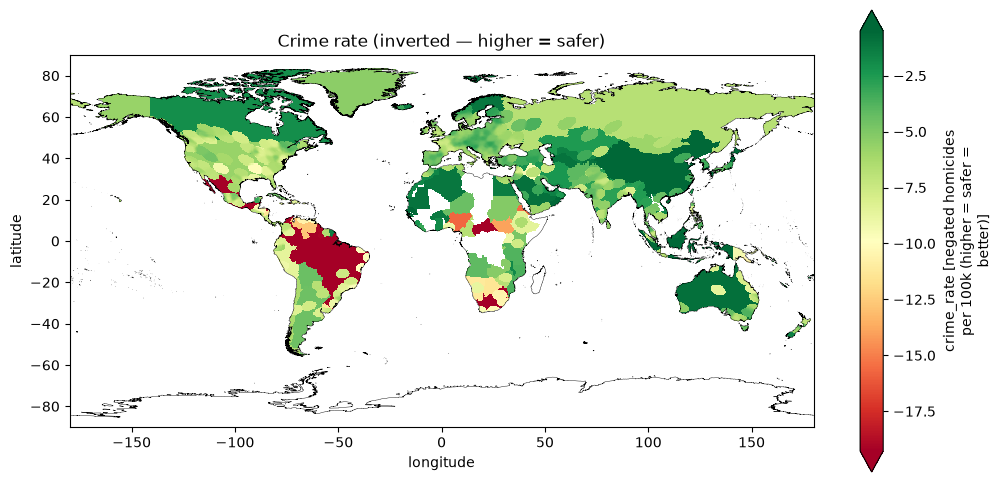

In [9]:
plot_map(values, cmap='RdYlGn', robust=True, title='Crime rate (inverted — higher = safer)')

## 9. Save

In [10]:
out = save_variable(values, VARIABLE)
print(f'wrote {out}')

wrote /Users/lutz/Documents/alfatraining/projects/data-science-notebooks/data/world-livable-atlas/processed/crime_rate.nc
